# Powder Average of Affinely Stretched Random-Line Spectra

This notebook assigns a radial \(k\) distribution, computes the corresponding isotropic random-line scattering spectrum, and compares three incompressible-uniaxial profiles: the isotropic input \(I_{\rm gt}\), the exact scalar spectral remapping, and the physical-arclength powder spectrum through second order in the Hencky strain.

For \(F=\operatorname{diag}(\lambda^{-1/2},\lambda^{-1/2},\lambda)\), the scalar result is evaluated by its exact one-dimensional angular quadrature. The physical-line result additionally uses the density--tangent and tangent--tangent correlations obtained from the same 12-dimensional conditional Gaussian sampling.

M_J direct_12d: 150/3001 r values (2.0s)
M_J direct_12d: 300/3001 r values (3.9s)
M_J direct_12d: 450/3001 r values (6.4s)
M_J direct_12d: 600/3001 r values (9.4s)
M_J direct_12d: 750/3001 r values (11.9s)
M_J direct_12d: 900/3001 r values (14.7s)
M_J direct_12d: 1050/3001 r values (18.5s)
M_J direct_12d: 1200/3001 r values (22.6s)
M_J direct_12d: 1350/3001 r values (25.5s)
M_J direct_12d: 1500/3001 r values (28.2s)
M_J direct_12d: 1650/3001 r values (30.9s)
M_J direct_12d: 1800/3001 r values (33.3s)
M_J direct_12d: 1950/3001 r values (35.7s)
M_J direct_12d: 2100/3001 r values (38.1s)
M_J direct_12d: 2250/3001 r values (40.5s)
M_J direct_12d: 2400/3001 r values (42.9s)
M_J direct_12d: 2550/3001 r values (45.2s)
M_J direct_12d: 2700/3001 r values (47.5s)
M_J direct_12d: 2850/3001 r values (50.0s)
M_J direct_12d: 3000/3001 r values (52.3s)
M_J direct_12d: 3001/3001 r values (52.3s)
distribution=gaussian_radial; sampling=quadrature
<k>=1; std(k)=0.15994892; k_eff=1.012711; rho0=0.10881781

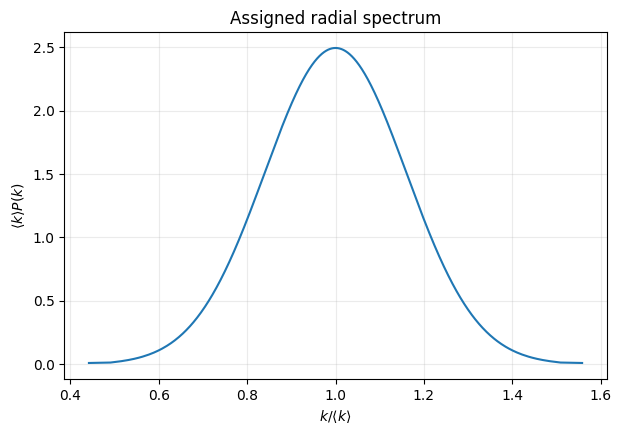

In [1]:
%matplotlib inline
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.legendre import leggauss
from scipy.special import erf, erfi
from scipy.interpolate import UnivariateSpline
import rw_line_scattering as rls
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.25})

# Radial-spectrum assignment.
k_distribution = "gaussian_radial"
k0_nominal = 1.0
k_distribution_params = {"r_sigma_k": 0.16}
r_sigma_k = k_distribution_params["r_sigma_k"]
k_sampling = "quadrature"  # deterministic radial nodes and weights
num_modes_k = 2**11
random_seed = 12345

# Isotropic line-scattering accuracy controls.
N_samp_U = 2**16
N_samp_tangent = 2**14
r_min_factor = 1e-3
r_max_factor = 250.0
r_split_factor = 5.0
Nr = 3000
Nr_small = 600
NQ = 260

line_result = rls.compute_uniform_line_scattering(
    k0_nominal=k0_nominal,
    r_sigma_k=r_sigma_k,
    k_distribution_params=k_distribution_params,
    k_distribution=k_distribution,
    k_sampling=k_sampling,
    num_modes_k=num_modes_k,
    random_seed=random_seed,
    Nr=Nr, Nr_small=Nr_small, NQ=NQ,
    r_min_factor=r_min_factor,
    r_max_factor=r_max_factor,
    r_grid_mode="mixed",
    r_split_factor=r_split_factor,
    Q_min_factor=0.1, Q_max_factor=20,
    N_samp_U=N_samp_U,
    jacobian_method="direct_12d",
    use_asymptotic=True,
    progress=True,
)
Q_input = np.asarray(line_result.Q_grid, float)
I_input = np.asarray(line_result.I_L, float)
k_radii = np.asarray(line_result.k_radii, float)
k_weights = np.asarray(line_result.k_weights, float)
k_mean = float(np.dot(k_weights, k_radii))
k_std = float(np.sqrt(np.dot(k_weights, (k_radii-k_mean)**2)))
k_eff = float(np.sqrt(line_result.mu2))
rho0 = float(line_result.rho0)
high_q = (Q_input/k_eff >= 5.0) & (Q_input/k_eff <= 30.0)
line_tail = float(np.median(Q_input[high_q]*I_input[high_q]))
print(f"distribution={k_distribution}; sampling={k_sampling}")
print(f"<k>={k_mean:.8g}; std(k)={k_std:.8g}; k_eff={k_eff:.8g}; rho0={rho0:.8g}")
print(f"high-Q check: median Q I={line_tail:.8g}; pi rho0={np.pi*rho0:.8g}")
fig, ax = plt.subplots()
density = k_weights/np.maximum(np.gradient(k_radii), np.finfo(float).tiny)
ax.plot(k_radii/k_mean, density*k_mean)
ax.set(xlabel=r"$k/\langle k\rangle$", ylabel=r"$\langle k\rangle P(k)$", title="Assigned radial spectrum")
plt.show()


## Powder-average functions

The general function uses a product Gauss-Legendre/periodic angular rule. The uniaxial function uses the exact one-dimensional reduction. Logarithmic interpolation is used only for the $Q$ coordinate; intensity itself is interpolated linearly so signed numerical values remain valid.


In [2]:
def principal_stretches(F):
    F = np.asarray(F, float)
    if F.shape != (3, 3) or not np.all(np.isfinite(F)) or np.linalg.det(F) <= 0:
        raise ValueError("F must be a finite orientation-preserving 3x3 tensor")
    return np.linalg.svd(F, compute_uv=False)

def input_intensity(Q):
    Q = np.asarray(Q, float)
    if np.any(Q < Q_input[0]) or np.any(Q > Q_input[-1]):
        raise ValueError("stretched Q arguments leave the input data range")
    return np.interp(np.log(Q), np.log(Q_input), I_input)

def powder_average(Q, F, intensity=input_intensity, amplitude=1.0, n_mu=96, n_phi=128):
    Q = np.asarray(Q, float)
    lam = principal_stretches(F)
    mu, wm = leggauss(n_mu)
    phi = 2*np.pi*(np.arange(n_phi)+0.5)/n_phi
    s = np.sqrt(np.maximum(0.0, 1-mu**2))
    nx = s[:, None]*np.cos(phi)[None, :]
    ny = s[:, None]*np.sin(phi)[None, :]
    nz = np.broadcast_to(mu[:, None], nx.shape)
    scale = np.sqrt((lam[0]*nx)**2+(lam[1]*ny)**2+(lam[2]*nz)**2)
    values = intensity(Q[:, None, None]*scale[None, :, :])
    return float(amplitude)*np.sum(values*wm[None, :, None], axis=(1, 2))/(2*n_phi)

def powder_average_uniaxial(Q, lambda_perp, lambda_parallel, intensity=input_intensity, amplitude=1.0, n_mu=192):
    mu, w = leggauss(n_mu)
    scale = np.sqrt(lambda_perp**2+(lambda_parallel**2-lambda_perp**2)*mu**2)
    values = intensity(np.asarray(Q)[:, None]*scale[None, :])
    return float(amplitude)*0.5*np.sum(values*w[None, :], axis=1)


## Incompressible uniaxial example

Here \(\lambda_\parallel=\lambda\), \(\lambda_\perp=\lambda^{-1/2}\), and \(\det F=1\). For numerical robustness, the exact scalar-remapping curve is used as the baseline and the second-order geometric-minus-scalar correction is added:

\[
\overline I_F^{\rm geom}
=\overline I_F^{\rm sc,exact}+T_H\left[
\frac{8}{15}I_L
+\frac{4}{15}\mathcal D_Q\mathcal I_{t\rho}
+\frac{2}{15}\mathcal I_{tt}
\right],
\qquad
T_H=\frac{3}{2}(\log\lambda)^2.
\]

This expression is identical through second order to the strict series containing \(\mathcal D_QI_L\) and \(\mathcal D_Q^2I_L\), but it resums the scalar coordinate remapping and avoids taking a noisy second derivative of the sampled isotropic spectrum. The logarithmic derivative \(\mathcal D_Q\mathcal I_{t\rho}\) is evaluated directly under the radial integral using \(\mathcal D_Qj_0(Qr)=\cos(Qr)-j_0(Qr)\), rather than differentiating an interpolated transform. Finite-window ringing in the tangent transforms is removed by using their even quadratic low-\(Q\) limits through \(Q/k_{\rm eff}=0.5\), with a smooth derivative-consistent blend to the direct transforms at \(Q/k_{\rm eff}=0.8\).

K_trho/K_tt direct_12d: 150/3001 r values (0.9s)
K_trho/K_tt direct_12d: 300/3001 r values (1.6s)
K_trho/K_tt direct_12d: 450/3001 r values (2.4s)
K_trho/K_tt direct_12d: 600/3001 r values (3.2s)
K_trho/K_tt direct_12d: 750/3001 r values (3.9s)
K_trho/K_tt direct_12d: 900/3001 r values (4.6s)
K_trho/K_tt direct_12d: 1050/3001 r values (5.3s)
K_trho/K_tt direct_12d: 1200/3001 r values (5.9s)
K_trho/K_tt direct_12d: 1350/3001 r values (6.5s)
K_trho/K_tt direct_12d: 1500/3001 r values (7.2s)
K_trho/K_tt direct_12d: 1650/3001 r values (7.9s)
K_trho/K_tt direct_12d: 1800/3001 r values (8.6s)
K_trho/K_tt direct_12d: 1950/3001 r values (9.3s)
K_trho/K_tt direct_12d: 2100/3001 r values (10.0s)
K_trho/K_tt direct_12d: 2250/3001 r values (10.8s)
K_trho/K_tt direct_12d: 2400/3001 r values (11.6s)
K_trho/K_tt direct_12d: 2550/3001 r values (12.4s)
K_trho/K_tt direct_12d: 2700/3001 r values (13.3s)
K_trho/K_tt direct_12d: 2850/3001 r values (14.1s)
K_trho/K_tt direct_12d: 3000/3001 r values (14.9s)

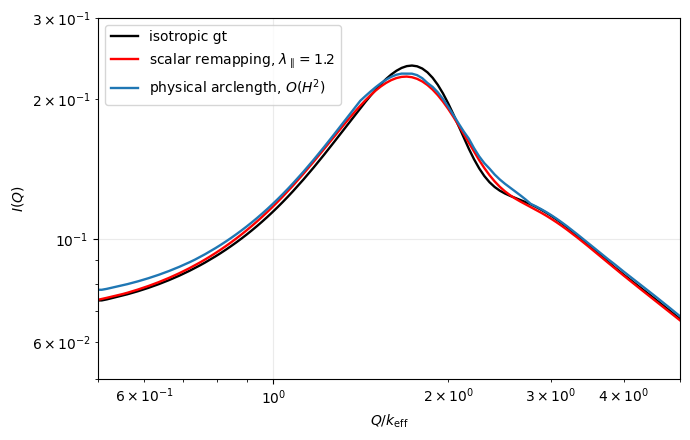

In [3]:
stretch_ratio = 1.2
lambda_parallel = stretch_ratio
lambda_perp = stretch_ratio**(-0.5)
F = np.diag([lambda_perp, lambda_perp, lambda_parallel])
lam = principal_stretches(F)

aniso_result = rls.compute_incompressible_uniaxial_scattering(
    stretch_ratio=stretch_ratio,
    line_result=line_result,
    N_samp_tangent=N_samp_tangent,
    tangent_use_qmc=True,
    tangent_random_seed=random_seed,
    n_mu=256,
    progress=True,
)
Q_powder = np.asarray(aniso_result.Q_grid, float)
I_gt = np.asarray(aniso_result.I_L, float)
I_scalar = np.asarray(aniso_result.I_scalar_exact, float)
I_scalar_second_order = np.asarray(aniso_result.I_scalar_second_order, float)
I_geom_second_order = np.asarray(aniso_result.I_geom_second_order, float)

# Backward-compatible names used by the scalar-series cells below.
I_powder = I_scalar
I_reference = I_scalar
A_F = 1.0

error_scale = max(float(np.max(np.abs(I_scalar))), 1e-14)
scalar_series_error = np.max(np.abs(I_scalar_second_order-I_scalar))/error_scale
print("principal stretches:", lam)
print(f"det(F)={np.linalg.det(F):.8g}; h=log(lambda)={aniso_result.hencky_strain:.8g}")
print(f"T_H={aniso_result.T_H:.8g}")
print(f"K_trho sampled baseline={aniso_result.K_trho_baseline:.3e}")
print(f"K_tt sampled baseline={aniso_result.K_tt_baseline:.3e}")
print(f"scalar O(H^2)/exact normalized max difference={scalar_series_error:.3e}")

output_dir = Path("rw_line_aniso_output")
output_dir.mkdir(exist_ok=True)
fig, ax = plt.subplots()
ax.loglog(Q_powder/k_eff, I_gt, label="isotropic gt", linewidth=1.7, color="black")
ax.loglog(
    Q_powder/k_eff,
    I_scalar,
    label=fr"scalar remapping, $\lambda_\parallel={stretch_ratio:g}$",
    linewidth=1.7,
    color="red",
)
ax.loglog(
    Q_powder/k_eff,
    I_geom_second_order,
    label=r"physical arclength, $O(H^2)$",
    linewidth=1.7,
    color="tab:blue",
)
ax.set(xlabel=r"$Q/k_{\rm eff}$", ylabel=r"$I(Q)$")
ax.set_xlim(0.5, 5)
ax.set_ylim(0.05, 0.3)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir/"incompressible_uniaxial_geometric_comparison.png", dpi=180)
plt.show()

## Closed-form Gaussian check

For the special input $I_0(Q)=e^{-aQ^2}$ the uniaxial integral is closed-form. Put $c=aQ^2(\lambda_\parallel^2-\lambda_\perp^2)$. The angular factor is $\sqrt{\pi}\,erf(\sqrt c)/(2\sqrt c)$ for $c>0$, one for $c=0$, and $\sqrt{\pi}\,erfi(\sqrt{-c})/(2\sqrt{-c})$ for $c<0$. This validates the quadrature; the random-line scattering curve is not Gaussian and uses the integral above.


In [4]:
def gaussian_closed(Q, a, lp, lz):
    Q = np.asarray(Q, float)
    c = a*Q**2*(lz**2-lp**2)
    f = np.ones_like(c)
    pos, neg = c > 1e-12, c < -1e-12
    f[pos] = np.sqrt(np.pi)*erf(np.sqrt(c[pos]))/(2*np.sqrt(c[pos]))
    f[neg] = np.sqrt(np.pi)*erfi(np.sqrt(-c[neg]))/(2*np.sqrt(-c[neg]))
    return np.exp(-a*Q**2*lp**2)*f

Qt = np.geomspace(1e-3, 3, 120)
a = 0.7
gaussian = lambda q: np.exp(-a*np.asarray(q)**2)
num = powder_average_uniaxial(Qt, lambda_perp, lambda_parallel, intensity=gaussian)
exact = gaussian_closed(Qt, a, lambda_perp, lambda_parallel)
print(f"closed-form Gaussian check: max abs error={np.max(np.abs(num-exact)):.3e}")


closed-form Gaussian check: max abs error=1.499e-15


## Log-stretch series expansion

Even when the angular integral has no closed form, it has a systematic series. Define the directional log-stretch $\delta(n)=\tfrac12\log(n^TFF^Tn)$ and $D=Q\,d/dQ=d/d\log Q$. Then $I_0(Qe^{\delta})=\sum_{m=0}^{\infty}\delta^m D^mI_0(Q)/m!$.

For better convergence we center the expansion at $\delta_0=\langle\delta\rangle_\Omega$. With $q_*=Qe^{\delta_0}$ and central moments $M_m=\langle(\delta-\delta_0)^m\rangle_\Omega$, the powder spectrum is $A_F\sum_m M_m D^mI_0(q_*)/m!$. Here $M_0=1$ and $M_1=0$, so the leading anisotropic correction is second order. The angular moments depend only on the stretch tensor and are calculated once. Since high derivatives amplify Monte Carlo and transform noise in the input curve, a weak smoothing spline in $\log Q$ is used. The implementation supports orders zero through three.


order 0: normalized RMS error=1.176e-02
order 1: normalized RMS error=1.176e-02
order 2: normalized RMS error=2.574e-03
order 3: normalized RMS error=2.240e-03
mean log-stretch delta0=0.010195012; central moments=[1.00000000e+00 0.00000000e+00 7.10968577e-03 2.76529755e-04]


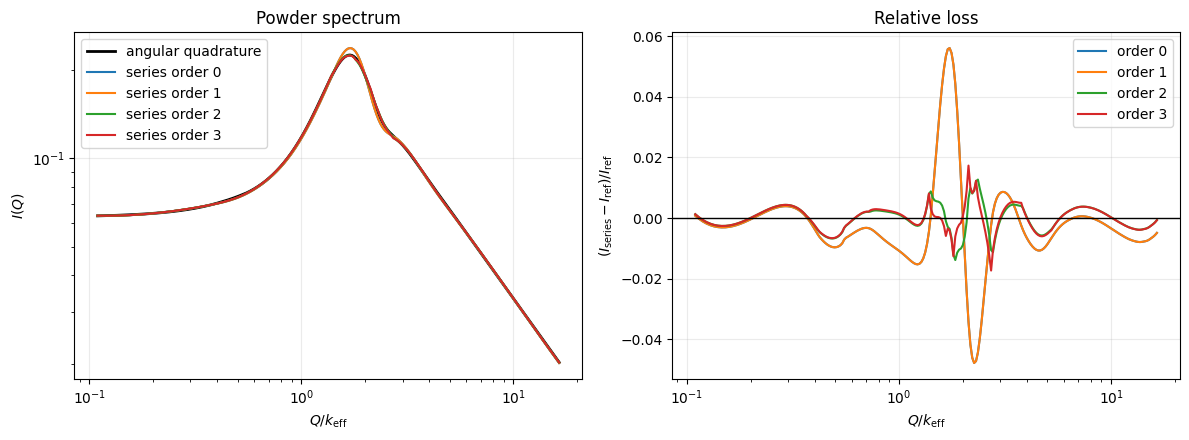

In [5]:
def log_stretch_moments(F, max_order=3, n_mu=160, n_phi=256):
    if not 0 <= max_order <= 3:
        raise ValueError("the cubic-spline implementation supports orders 0 through 3")
    lam = principal_stretches(F)
    mu, wm = leggauss(n_mu)
    phi = 2*np.pi*(np.arange(n_phi)+0.5)/n_phi
    s = np.sqrt(np.maximum(0.0, 1-mu**2))
    nx = s[:, None]*np.cos(phi)[None, :]
    ny = s[:, None]*np.sin(phi)[None, :]
    nz = np.broadcast_to(mu[:, None], nx.shape)
    delta = 0.5*np.log((lam[0]*nx)**2+(lam[1]*ny)**2+(lam[2]*nz)**2)
    average = lambda x: np.sum(x*wm[:, None])/(2*n_phi)
    delta0 = float(average(delta))
    centered = delta-delta0
    moments = np.array([1.0]+[average(centered**m) for m in range(1, max_order+1)])
    return delta0, moments

def powder_average_series(Q, F, order=3, amplitude=1.0, smoothing_fraction=1e-4):
    delta0, moments = log_stretch_moments(F, max_order=order)
    smoothing = float(smoothing_fraction)*len(I_input)*np.var(I_input)
    spline = UnivariateSpline(np.log(Q_input), I_input, k=3, s=smoothing)
    x_star = np.log(np.asarray(Q, float))+delta0
    if np.any(x_star < np.log(Q_input[0])) or np.any(x_star > np.log(Q_input[-1])):
        raise ValueError("series expansion point leaves the input data range")
    result = np.zeros_like(x_star)
    for m in range(order+1):
        result += moments[m]*spline(x_star, nu=m)/math.factorial(m)
    return float(amplitude)*result, delta0, moments

series_curves = {}
for order in range(4):
    curve, delta0, moments = powder_average_series(Q_powder, F, order=order, amplitude=A_F)
    series_curves[order] = curve
    scale = np.maximum(np.max(np.abs(I_powder)), 1e-14)
    rms = np.sqrt(np.mean((curve-I_powder)**2))/scale
    print(f"order {order}: normalized RMS error={rms:.3e}")
print(f"mean log-stretch delta0={delta0:.8g}; central moments={moments}")

fig, (ax, ax_loss) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
ax.loglog(Q_powder/k_eff, I_reference, color="black", lw=2, label="angular quadrature")
relative_floor = 1e-8*np.max(np.abs(I_reference))
reliable = np.abs(I_reference) > relative_floor
for order, curve in series_curves.items():
    line, = ax.loglog(Q_powder/k_eff, np.abs(curve), label=f"series order {order}")
    relative_loss = np.full_like(curve, np.nan)
    relative_loss[reliable] = (curve[reliable]-I_reference[reliable])/I_reference[reliable]
    ax_loss.semilogx(Q_powder/k_eff, relative_loss, color=line.get_color(), label=f"order {order}")
ax.set(xlabel=r"$Q/k_{\rm eff}$", ylabel=r"$I(Q)$", title="Powder spectrum")
ax_loss.axhline(0.0, color="black", lw=1)
ax_loss.set(xlabel=r"$Q/k_{\rm eff}$", ylabel=r"$(I_{\rm series}-I_{\rm ref})/I_{\rm ref}$", title="Relative loss")
ax.legend()
ax_loss.legend()
fig.tight_layout()
plt.show()


## Scope

The scalar-remapping curve is exact for the tabulated isotropic spectrum and the specified uniaxial stretch. The physical-arclength curve is complete through second order in a weak incompressible Hencky strain. Its density--density, tangent--density, and tangent--tangent pieces are assembled from one-dimensional radial transforms, without rotating the conditional samples through laboratory orientations. Higher tangent moments are required for a finite-strain geometric result beyond this order.

In [6]:
output_dir = Path("rw_line_aniso_output")
output_dir.mkdir(exist_ok=True)
np.savez(
    output_dir/"aniso_powder_data.npz",
    Q_input=Q_input,
    I_input=I_input,
    k_radii=k_radii,
    k_weights=k_weights,
    r_grid=line_result.r_grid,
    C_L=line_result.C_L,
    K_trho=aniso_result.K_trho,
    K_tt=aniso_result.K_tt,
    K_trho_baseline=aniso_result.K_trho_baseline,
    K_tt_baseline=aniso_result.K_tt_baseline,
    Q=Q_powder,
    I_gt=I_gt,
    I_scalar=I_scalar,
    I_scalar_second_order=I_scalar_second_order,
    I_geom_second_order=I_geom_second_order,
    I_trho=aniso_result.I_trho,
    I_tt=aniso_result.I_tt,
    D_I_L=aniso_result.D_I_L,
    D2_I_L=aniso_result.D2_I_L,
    D_I_trho=aniso_result.D_I_trho,
    I_series_order0=series_curves[0],
    I_series_order1=series_curves[1],
    I_series_order2=series_curves[2],
    I_series_order3=series_curves[3],
    F=F,
    principal_stretches=lam,
    stretch_ratio=stretch_ratio,
    hencky_strain=aniso_result.hencky_strain,
    T_H=aniso_result.T_H,
    lambda_perp=lambda_perp,
    lambda_parallel=lambda_parallel,
    k0_nominal=k0_nominal,
    r_sigma_k=r_sigma_k,
    k_eff=k_eff,
    rho0=rho0,
)
print(f"saved data to {output_dir.resolve()}")

saved data to C:\Users\ccu\Documents\codex_projects\project_randomcxl\smpl\rw_line_aniso_output
